In [1]:
%load_ext autoreload
%autoreload 2

import torch
import numpy as np
import sys, os
from sklearn.datasets import make_blobs

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from src.models.modules.binarize import BinarizeAblationLayer
from src.visualization.style import set_paper_style
from src.visualization.relationship import plot_manifold_collapse_comparison

set_paper_style()

## 3. Sự cần thiết của Linear Bottleneck: Tránh hiện tượng Manifold Collapse

Trong các mạng nơ-ron thực (real-valued networks) như MobileNetV2, cấu trúc **Linear Bottleneck** (loại bỏ hàm phi tuyến ở các layer có số kênh nhỏ) được sử dụng để tránh mất mát thông tin. Đối với mạng nhị phân (Binarized Neural Networks - BNNs) như **HBCC**, điều này không chỉ là một thủ thuật tối ưu mà là một **yêu cầu bắt buộc**.

Giả sử không gian đặc trưng của chúng ta đi qua một hàm phi tuyến tính quen thuộc như ReLU: $f(x) = \max(0, x)$, sau đó được nhị phân hóa bằng hàm Sign nghiêm ngặt: 
$$
Sign(x) = \begin{cases} 
      1 & x \geq 0 \\
      -1 & x < 0 
   \end{cases}
$$

**Hiện tượng sụp đổ không gian (Manifold Collapse):**
Nếu một cụm đặc trưng (cluster) có giá trị âm, khi đi qua ReLU, toàn bộ cụm này sẽ bị ép về $0$. Tiếp theo, hàm Sign sẽ ánh xạ tất cả các số $0$ này thành $1$. Kết quả là, cả cụm đặc trưng âm và cụm đặc trưng dương đều bị ánh xạ chung vào một điểm duy nhất là $+1$. Luồng thông tin (gradient) bị triệt tiêu hoàn toàn và mạng không thể phân loại được dữ liệu.

Notebook này trực quan hóa hiện tượng trên bằng dữ liệu 2D mô phỏng.

In [2]:
X_np, y = make_blobs(n_samples=600, centers=[[-3, -3], [3, 3]], cluster_std=1.2)
X_tensor = torch.tensor(X_np, dtype=torch.float32)

In [3]:
bad_layer = BinarizeAblationLayer(use_activation=True)   # Có ReLU
good_layer = BinarizeAblationLayer(use_activation=False) # Linear Bottleneck

with torch.no_grad():
    out_bad = bad_layer(X_tensor).numpy()
    out_good = good_layer(X_tensor).numpy()

# Thêm jitter để dễ quan sát các điểm trùng tọa độ {-1, 1}
def jitter(data): return data + np.random.randn(*data.shape) * 0.15

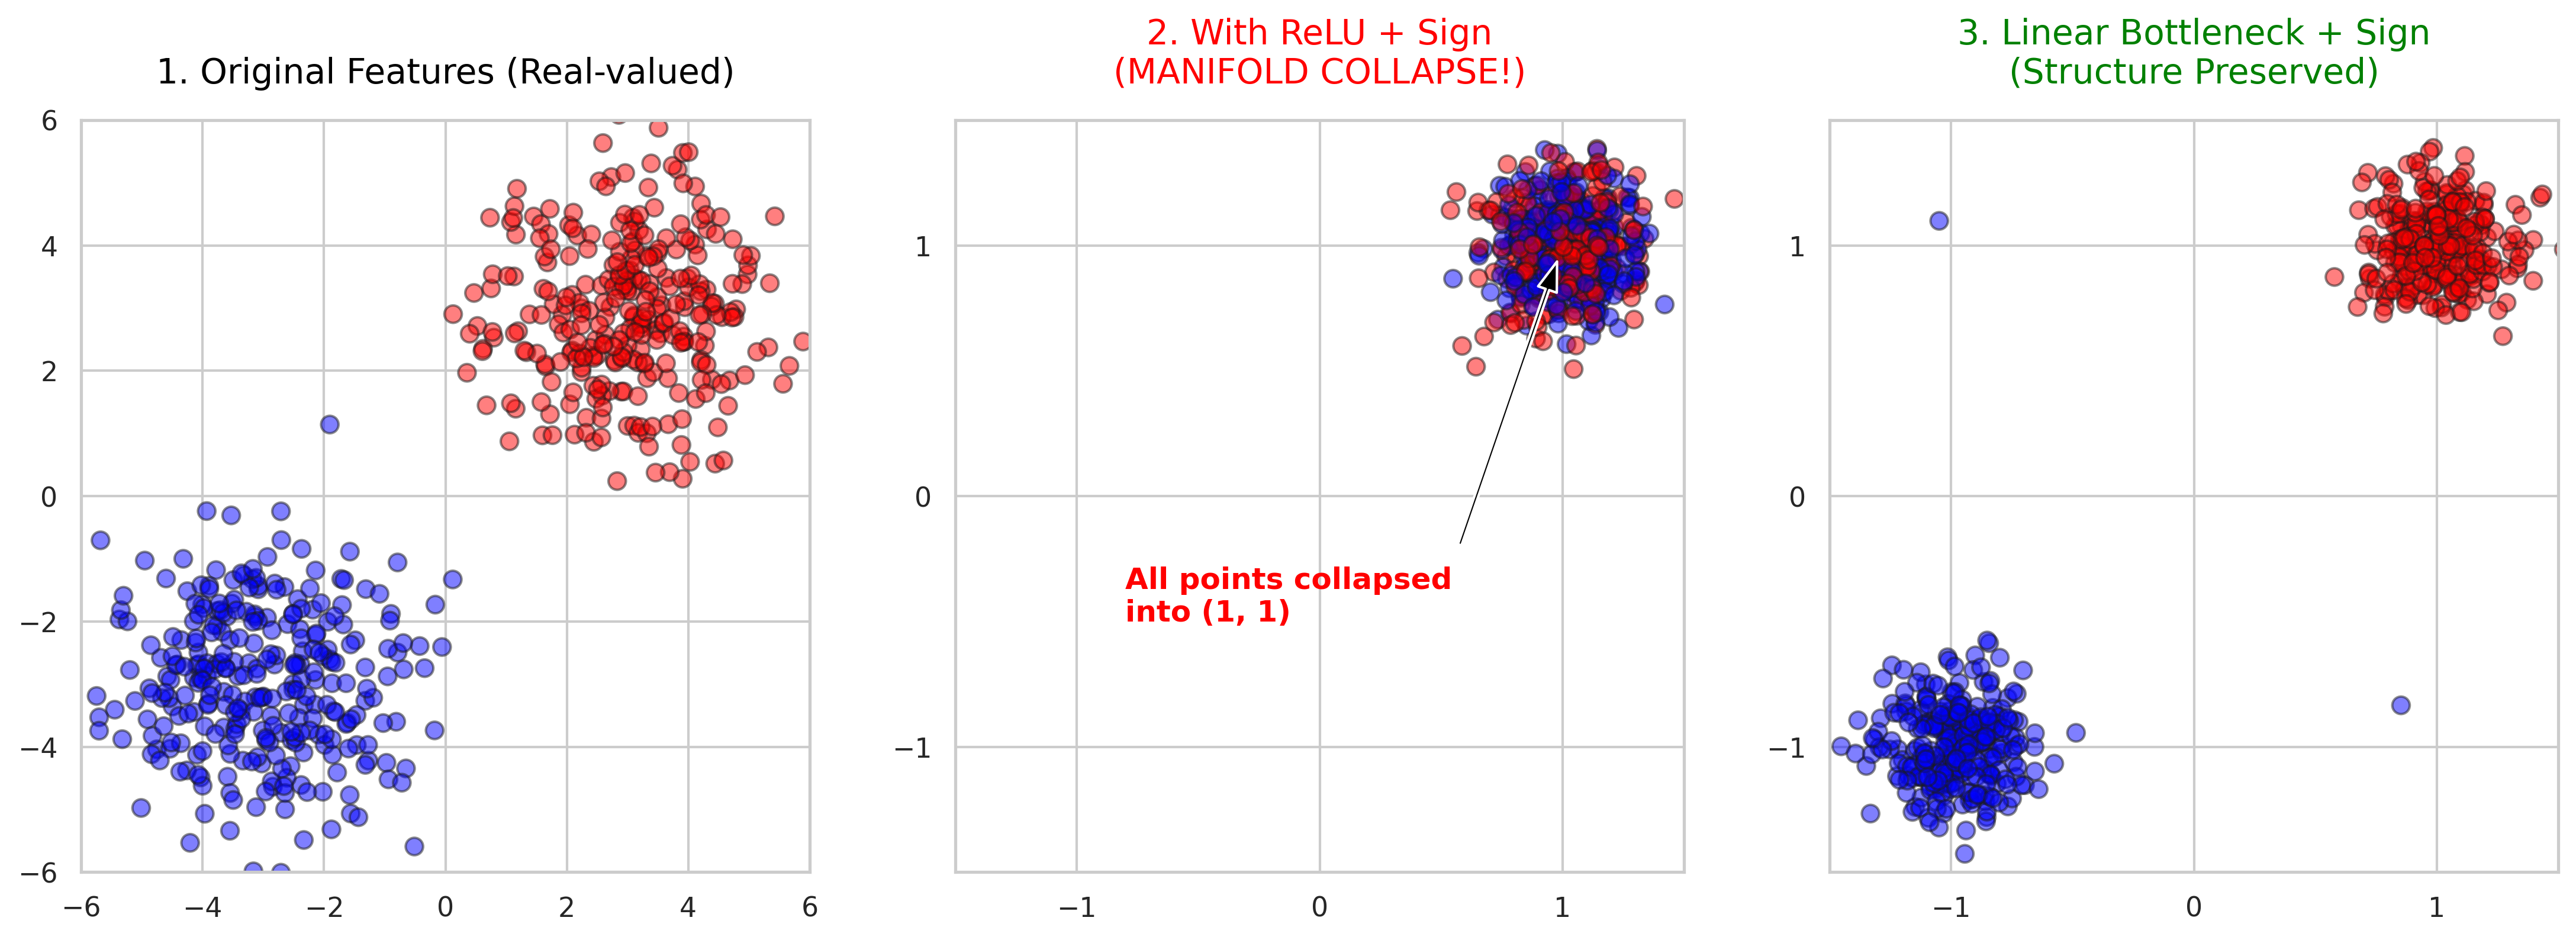

In [4]:
plot_manifold_collapse_comparison(
    X_real=X_np, 
    X_relu=jitter(out_bad), 
    X_linear=jitter(out_good), 
    labels=y,
    save_path='../paper/figures/03_manifold_collapse.png'
)